In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import os
import time
from PIL import Image
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Dense 


In [9]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall


In [3]:
#Dataset Information
print("TRAIN")
print("Bird:", len(os.listdir("aerial_dataset/train/bird")))
print("Drone:", len(os.listdir("aerial_dataset/train/drone")))

print("\nVALID")
print("Bird:", len(os.listdir("aerial_dataset/valid/bird")))
print("Drone:", len(os.listdir("aerial_dataset/valid/drone")))

print("\nTEST")
print("Bird:", len(os.listdir("aerial_dataset/test/bird")))
print("Drone:", len(os.listdir("aerial_dataset/test/drone")))

TRAIN
Bird: 1414
Drone: 1248

VALID
Bird: 217
Drone: 225

TEST
Bird: 121
Drone: 94


In [4]:
tbird_path = "aerial_dataset/train/bird"
tdrone_path = "aerial_dataset/train/drone"
tbird_images = os.listdir(tbird_path)
tdrone_images = os.listdir(tdrone_path)

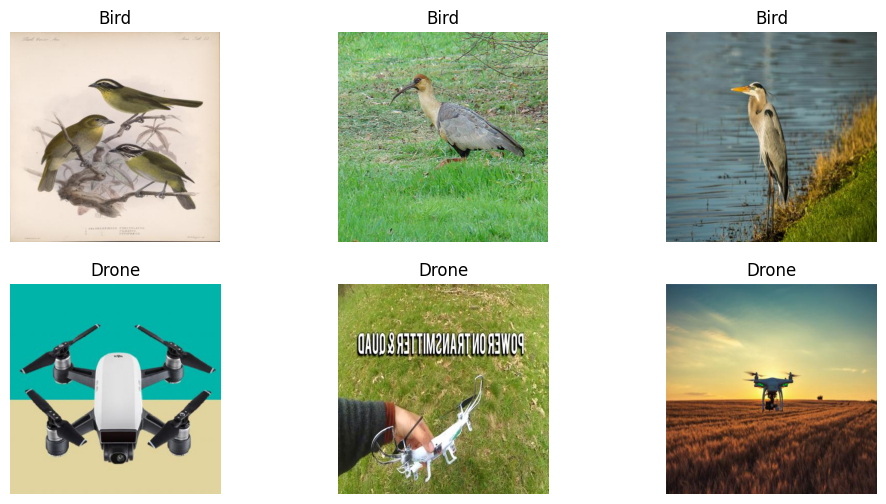

In [5]:
#Sample Images
plt.figure(figsize=(12,6))
for i in range(3):
    bird_img = random.choice(tbird_images)
    img = Image.open(
        os.path.join(tbird_path, bird_img)
    )
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Bird")
    plt.axis("off")
for i in range(3):
    drone_img = random.choice(tdrone_images)
    img = Image.open(
        os.path.join(tdrone_path, drone_img)
    )
    plt.subplot(2,3,i+4)
    plt.imshow(img)
    plt.title("Drone")
    plt.axis("off")
plt.show()

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
cnn_train_data = cnn_train_datagen.flow_from_directory(
    "aerial_dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    interpolation='bilinear'
)
cnn_valid_datagen = ImageDataGenerator(
    rescale=1./255
)
cnn_valid_data = cnn_valid_datagen.flow_from_directory(
    "aerial_dataset/valid",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    interpolation='bilinear'

)
cnn_test_datagen = ImageDataGenerator(
    rescale=1./255
)
cnn_test_data = cnn_test_datagen.flow_from_directory(
    "aerial_dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    interpolation='bilinear'

)
print("Class Labels:")
print(cnn_train_data.class_indices)
print("\nDataset Loaded Successfully")

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class Labels:
{'bird': 0, 'drone': 1}

Dataset Loaded Successfully


In [7]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.layers import Dropout


cnn_model = Sequential()
cnn_model.add(
    Conv2D(32,(3,3),activation='relu',
        input_shape=(224,224,3),padding='same'
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.25))
cnn_model.add(
    Conv2D(64, (3,3),activation='relu'
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.25))
cnn_model.add(
    Conv2D(128,(3,3),activation='relu'
    )
)
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.25))

cnn_model.add(GlobalAveragePooling2D())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(2, activation='softmax'))

d:\vscode\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [12]:
cnn_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
cnn_checkpoint = ModelCheckpoint(
    "cnn_best_bird_drone_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [13]:
cnn_start_time = time.time()
cnn_history = cnn_model.fit(
    cnn_train_data,
    validation_data=cnn_valid_data,
    epochs=15,
    callbacks=[cnn_early_stop, cnn_checkpoint]
)
cnn_end_time = time.time()
cnn_training_time = cnn_end_time - cnn_start_time


Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6368 - loss: 0.7139 - precision: 0.6368 - recall: 0.6368
Epoch 1: val_accuracy improved from None to 0.49095, saving model to cnn_best_bird_drone_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.6570 - loss: 0.6661 - precision: 0.6570 - recall: 0.6570 - val_accuracy: 0.4910 - val_loss: 0.7048 - val_precision: 0.4910 - val_recall: 0.4910
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6970 - loss: 0.5918 - precision: 0.6970 - recall: 0.6970
Epoch 2: val_accuracy did not improve from 0.49095
84/84 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.6998 - loss: 0.5853 - precision: 0.6998 - recall: 0.6998 - val_accuracy: 0.4910 - val_loss: 0.7091 - val_precision: 0.4910 - val_recall: 0.4910
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7016 - loss: 0.5871 - precision: 0.7016 - recall: 0.7016
Epoch 3: val_accuracy improved from 0.49095 to 0.49548, saving model to cnn_best_bird_drone_

In [31]:
cnn_test_loss, cnn_test_accuracy, cnn_test_precision, cnn_test_recall = cnn_model.evaluate(cnn_test_data)
cnn_predictions = cnn_model.predict(cnn_test_data)
cnn_predicted_classes = np.argmax(
    cnn_predictions,
    axis=1
)
cnn_true_classes = cnn_test_data.classes
cnn_f1 = f1_score(
    cnn_true_classes,
    cnn_predicted_classes,
    average='weighted'
)
print("\nCNN F1 Score:", cnn_f1)
cnn_cm = confusion_matrix(
    cnn_true_classes,
    cnn_predicted_classes
)
print("\nConfusion Matrix:\n")
print(cnn_cm)
print("\nClassification Report:\n")
print(
    classification_report(
        cnn_true_classes,
        cnn_predicted_classes,
        target_names=cnn_test_data.class_indices.keys()
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.8047 - loss: 0.3975 - precision: 0.8047 - recall: 0.8047
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 385ms/step

CNN F1 Score: 0.8021338712910987

Confusion Matrix:

[[107  14]
 [ 28  66]]

Classification Report:

              precision    recall  f1-score   support

        bird       0.79      0.88      0.84       121
       drone       0.82      0.70      0.76        94

    accuracy                           0.80       215
   macro avg       0.81      0.79      0.80       215
weighted avg       0.81      0.80      0.80       215



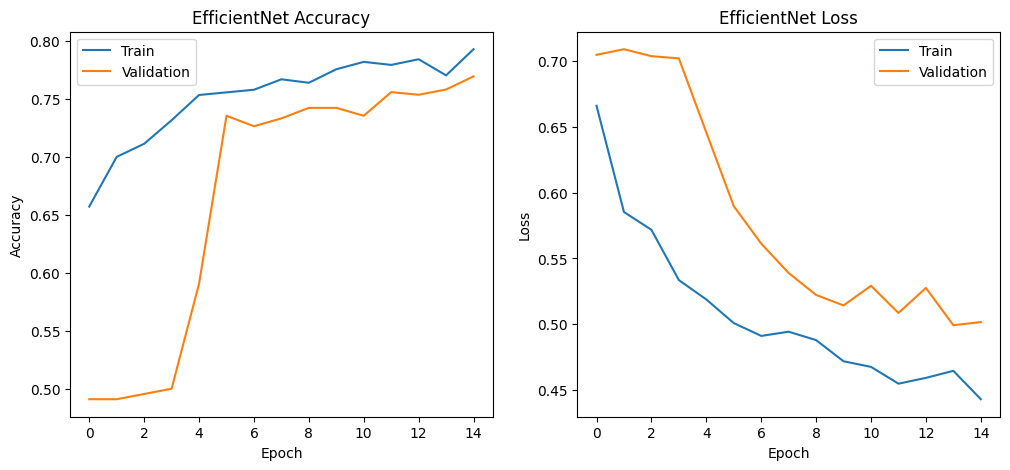

In [28]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title("EfficientNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.subplot(1,2,2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title("EfficientNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [16]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


In [17]:
eff_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

In [18]:
eff_valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
eff_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
eff_train_data = eff_train_datagen.flow_from_directory(
    "aerial_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=42
)
eff_valid_data = eff_valid_datagen.flow_from_directory(
    "aerial_dataset/valid",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
eff_test_data = eff_test_datagen.flow_from_directory(
    "aerial_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [19]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False
eff_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 17s 1us/step


In [20]:
eff_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

In [21]:
eff_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
eff_checkpoint = ModelCheckpoint(
    "best_efficientnet_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [22]:
eff_start_time = time.time()
eff_history = eff_model.fit(
    eff_train_data,
    validation_data=eff_valid_data,
    epochs=15,
    callbacks=[eff_early_stop, eff_checkpoint]
)
eff_end_time = time.time()
eff_training_time = eff_end_time - eff_start_time

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6909 - loss: 0.5791 - precision: 0.6909 - recall: 0.6909
Epoch 1: val_accuracy improved from None to 0.95701, saving model to best_efficientnet_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8065 - loss: 0.4232 - precision: 0.8065 - recall: 0.8065 - val_accuracy: 0.9570 - val_loss: 0.1920 - val_precision: 0.9570 - val_recall: 0.9570
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9387 - loss: 0.1884 - precision: 0.9387 - recall: 0.9387
Epoch 2: val_accuracy improved from 0.95701 to 0.96606, saving model to best_efficientnet_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9403 - loss: 0.1848 - precision: 0.9403 - recall: 0.9403 - val_accuracy: 0.9661 - val_loss: 0.1227 - val_precision: 0.9661 - val_recall: 0.9661
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.9619 - loss: 0.1367 - precision: 0.9619 - recall: 0.9619 
Epoch 3: val_accuracy improved from 0.966

In [32]:
eff_test_loss, eff_test_accuracy, eff_test_precision, eff_test_recall = eff_model.evaluate(eff_test_data)
eff_test_data.reset()
eff_predictions = eff_model.predict(eff_test_data)
eff_predicted_classes = np.argmax(
    eff_predictions,
    axis=1
)
eff_true_classes = eff_test_data.classes
eff_f1 = f1_score(
    eff_true_classes,
    eff_predicted_classes,
    average='weighted'
)
print("\nEFF F1 Score:", eff_f1)
eff_cm = confusion_matrix(
    eff_true_classes,
    eff_predicted_classes
)
print("\nConfusion Matrix:")
print(eff_cm)
print("\nClassification Report:")
print(
    classification_report(
        eff_true_classes,
        eff_predicted_classes,
        target_names=eff_test_data.class_indices.keys()
    )
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9767 - loss: 0.0655 - precision: 0.9767 - recall: 0.9767
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

EFF F1 Score: 0.9767298561948204

Confusion Matrix:
[[119   2]
 [  3  91]]

Classification Report:
              precision    recall  f1-score   support

        bird       0.98      0.98      0.98       121
       drone       0.98      0.97      0.97        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



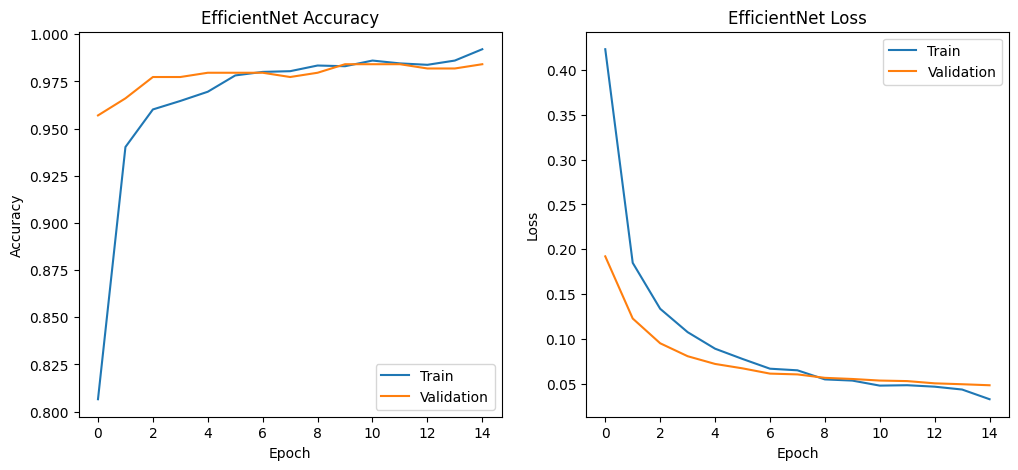

In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(eff_history.history['accuracy'])
plt.plot(eff_history.history['val_accuracy'])
plt.title("EfficientNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.subplot(1,2,2)
plt.plot(eff_history.history['loss'])
plt.plot(eff_history.history['val_loss'])
plt.title("EfficientNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [35]:
import pandas as pd

comparison_df = pd.DataFrame({'Model': ['Custom CNN', 'EfficientNetB0'],
    'Accuracy': [
        cnn_test_accuracy,
        eff_test_accuracy
    ],
    'Precision': [
        cnn_test_precision,
        eff_test_precision
    ],
    'Recall': [
        cnn_test_recall,
        eff_test_recall
    ],
    'F1 Score': [
        cnn_f1,
        eff_f1
    ],
    'Training Time (min)': [
        cnn_training_time / 60,
        eff_training_time / 60
    ]
})
comparison_df = comparison_df.round(4)
print(comparison_df)

            Model  Accuracy  Precision  Recall  F1 Score  Training Time (min)
0      Custom CNN    0.8047     0.8047  0.8047    0.8021              64.1848
1  EfficientNetB0    0.9767     0.9767  0.9767    0.9767              69.1957


In [36]:
eff_model.save("best_efficientnet_model.keras")